In [28]:
import yfinance as yf
import pandas as pd
import numpy as np
import datetime as dt 
import matplotlib.pyplot as plt
import pmdarima as pm
import statsmodels.api as sm
import scipy.stats as stats
from statsmodels.tsa.arima.model import ARIMA
from pmdarima import auto_arima
from arch import arch_model
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.stattools import adfuller, kpss
from statsmodels.tsa.statespace.sarimax import SARIMAX
from statsmodels.stats.diagnostic import acorr_ljungbox
from sklearn.metrics import mean_squared_error, mean_absolute_error

In [29]:
# Define the ticker symbol for the Shanghai Composite Index
ticker = '000001.SS'

# Define the date range
start_date = '2014-01-01'
end_date = '2024-01-01'

# Download the full dataset sourced from yahoo finance
data = yf.download(ticker, start=start_date, end=end_date)

print(pd.concat([data.head(1), data.tail(1)]))


[*********************100%%**********************]  1 of 1 completed

                   Open         High          Low        Close    Adj Close  \
Date                                                                          
2014-01-02  2112.125977  2113.110107  2101.016113  2109.386963  2109.386963   
2023-12-29  2950.836914  2975.031982  2950.017090  2974.935059  2974.935059   

            Volume  
Date                
2014-01-02   68500  
2023-12-29  290700  


In [30]:
# Extract close price as our target data, denoted by X
X = data.Close

# Perform the Augmented Dickey-Fuller (ADF) test to check if the time series is stationary
result = adfuller(X)
# Print the test statistic - a more negative value indicates a higher likelihood of stationarity
print('Dickey-Fuller Statistic: %f' % result[0])
# Print the p-value - a lower value (typically < 0.05) means we can reject the null hypothesis of non-stationarity
print('p-value: %f' % result[1])
# Print the critical values at different confidence levels (1%, 5%, and 10%) - the thresholds for the test statistic
print('Critical Values:')
for key, value in result[4].items():
    print('\t%s: %.3f' % (key, value))

# Perform the Kwiatkowski-Phillips-Schmidt-Shin (KPSS) test to check if the time series is stationary
result_kpss = kpss(X, regression='c')
# Print the KPSS test statistic - a higher value indicates a higher likelihood of non-stationarity
print('KPSS Statistic: %f' % result_kpss[0])
# Print the p-value - a higher value (typically > 0.05) means we cannot reject the null hypothesis of stationarity
print('p-value: %f' % result_kpss[1])
# Print the critical values at different confidence levels (10%, 5%, 2.5%, and 1%) - the thresholds for the test statistic
print('Critical Values:')
for key, value in result_kpss[3].items():
    print('\t%s: %.3f' % (key, value))

Adata Statistic: -9.738395
p-value: 0.000000
Critical Values:
	1%: -3.433
	5%: -2.863
	10%: -2.567
KPSS Statistic: 0.101244
p-value: 0.100000
Critical Values:
	10%: 0.347
	5%: 0.463
	2.5%: 0.574
	1%: 0.739


c:\Users\p0f3h\anaconda3\envs\2024project\lib\site-packages\statsmodels\tsa\stattools.py:2022: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is greater than the p-value returned.

  warnings.warn(


In [31]:
# Define a function for train-test split
def train_test_split(X, size=0.9):
    train = X[:int(X.shape[0]*size)]
    test = X[int(X.shape[0]*size):]
    return train, test

# Split train set and test set
train, test = train_test_split(X=data['Close'], size=0.9)

In [32]:
# Train an ARIMA model using the auto_arima function on the training data
arima_model = auto_arima(train, trace=True, error_action='ignore', suppress_warnings=True)

# Print a summary of the fitted ARIMA model
print(arima_model.summary())

Performing stepwise search to minimize aic
 ARIMA(2,1,2)(0,0,0)[0] intercept   : AIC=22799.542, Time=1.44 sec
 ARIMA(0,1,0)(0,0,0)[0] intercept   : AIC=22865.142, Time=0.03 sec
 ARIMA(1,1,0)(0,0,0)[0] intercept   : AIC=22858.123, Time=0.06 sec
 ARIMA(0,1,1)(0,0,0)[0] intercept   : AIC=22856.954, Time=0.08 sec
 ARIMA(0,1,0)(0,0,0)[0]             : AIC=22863.357, Time=0.03 sec
 ARIMA(1,1,2)(0,0,0)[0] intercept   : AIC=22855.182, Time=0.28 sec
 ARIMA(2,1,1)(0,0,0)[0] intercept   : AIC=22854.259, Time=0.29 sec
 ARIMA(3,1,2)(0,0,0)[0] intercept   : AIC=22779.514, Time=1.34 sec
 ARIMA(3,1,1)(0,0,0)[0] intercept   : AIC=22850.379, Time=0.58 sec
 ARIMA(4,1,2)(0,0,0)[0] intercept   : AIC=22781.262, Time=1.09 sec
 ARIMA(3,1,3)(0,0,0)[0] intercept   : AIC=inf, Time=1.53 sec
 ARIMA(2,1,3)(0,0,0)[0] intercept   : AIC=22861.508, Time=1.08 sec
 ARIMA(4,1,1)(0,0,0)[0] intercept   : AIC=22839.624, Time=0.37 sec
 ARIMA(4,1,3)(0,0,0)[0] intercept   : AIC=22783.030, Time=1.44 sec
 ARIMA(3,1,2)(0,0,0)[0]  

In [33]:
# Extract residuals from ARIMA model
arima_residuals = arima_model.resid()

# Define FIGARCH model function
def figarch_model(data, p=1, q=1, d=0.99
, mean='constant', dist='normal'):
    model = arch_model(
        data, 
        p=p, q=q, 
        mean=mean, 
        vol='FIGARCH', 
        power=d,  # FIGARCH uses the 'power' parameter to indicate d
        dist=dist
    )
    return model

# Apply FIGARCH model to ARIMA residuals
FIGARCH = figarch_model(arima_residuals)
# Fit the FIGARCH model
figarch_results = FIGARCH.fit(disp='off', show_warning=False)

# Display FIGARCH model fitting summary
print(figarch_results.summary())

               Constant Mean - Power FIGARCH (power: 1.0) Model Results               
Dep. Variable:                           None   R-squared:                       0.000
Mean Model:                     Constant Mean   Adj. R-squared:                  0.000
Vol Model:         Power FIGARCH (power: 1.0)   Log-Likelihood:               -10987.7
Distribution:                          Normal   AIC:                           21985.4
Method:                    Maximum Likelihood   BIC:                           22013.8
                                                No. Observations:                 2187
Date:                        Mon, Jul 22 2024   Df Residuals:                     2186
Time:                                14:17:10   Df Model:                            1
                                 Mean Model                                
                 coef    std err          t      P>|t|     95.0% Conf. Int.
-----------------------------------------------------------------

In [34]:
# Function to perform one-step forecast
def one_step_forecast():
    arima_forecast, conf_int = arima_model.predict(n_periods=1, return_conf_int=True)
    figarch_forecast = figarch_results.forecast(horizon=1)
    return (
        arima_forecast.tolist()[0],
        np.asarray(conf_int).tolist()[0],
        figarch_forecast.variance.values[-1, 0]  # Access the forecasted variance correctly
    )

arima_predictions = []
confidence_intervals = []
figarch_predictions = []

for x in test:
    arima_forecast, conf, figarch_forecast = one_step_forecast()
    arima_predictions.append(arima_forecast)
    confidence_intervals.append(conf)
    figarch_predictions.append(figarch_forecast)
    
    # Update the ARIMA model
    arima_model.update(x)
    arima_residuals = arima_model.resid()
    # Refit the FIGARCH model with the updated data
    figarch_results = figarch_model(arima_residuals)
    figarch_results = figarch_results.fit(disp="off", show_warning=False)


c:\Users\p0f3h\anaconda3\envs\2024project\lib\site-packages\statsmodels\tsa\base\tsa_model.py:834: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(


MAE: 30.780294712785317
RMSE: 36.63744282645401
MAPE: 0.9703365769743165%


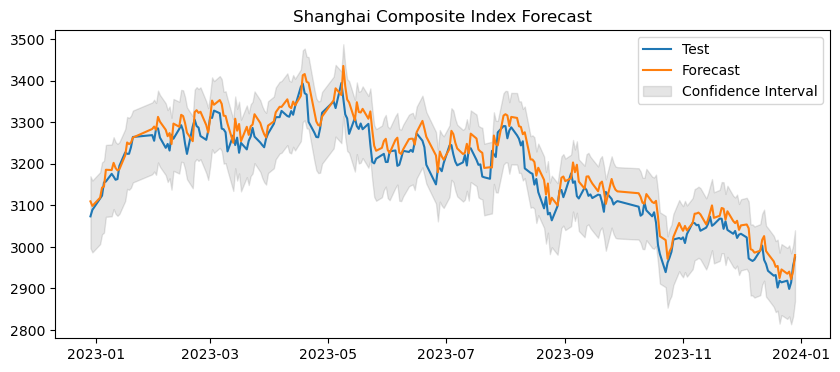

In [35]:
# Combine ARIMA and GARCH Forecasts
arima_forecast_series = pd.Series(arima_predictions, index=test.index)
conf_int_df = pd.DataFrame(confidence_intervals, index=test.index, columns=['lower', 'upper'])
figarch_forecast_series = pd.Series(figarch_predictions, index=test.index)
final_forecast = arima_forecast_series + np.sqrt(figarch_forecast_series)

# Evaluate the Forecast
mae = mean_absolute_error(test, final_forecast)
rmse = np.sqrt(mean_squared_error(test, final_forecast))
mape = np.mean(np.abs((test - final_forecast) / test)) * 100

# Print the evaluation metrics
print(f'MAE: {mae}')
print(f'RMSE: {rmse}')
print(f'MAPE: {mape}%')

# Plot the results
plt.figure(figsize=(10, 4))
plt.plot(test, label='Test')
plt.plot(final_forecast, label='Forecast')
plt.fill_between(conf_int_df.index, conf_int_df['lower'], conf_int_df['upper'], color='k', alpha=0.1, label='Confidence Interval')
plt.title('Shanghai Composite Index Forecast')
plt.legend()
plt.show()